# 03: From-Scratch Deep Model (CNN / BiLSTM)

A PyTorch text classifier trained from random initialization: an embedding layer,
a multi-kernel 1-D CNN (or BiLSTM with attention), and an MLP head. This
satisfies the "build/adapt a model" requirement. We run light hyperparameter
exploration and reserve the compute budget for the ModernBERT ablations.

In [1]:
import json
from torch.utils.data import DataLoader
import torch.nn as nn

from wcc.data import PROCESSED_DIR, load_processed
from wcc.datasets import ScratchTextDataset, scratch_collate
from wcc.metrics import (
    compute_metrics,
    confusion,
    plot_confusion_matrix,
    plot_training_curves,
    print_report,
)
from wcc.train import _evaluate_scratch, get_device, train_scratch_model

train, val, test, label_map = load_processed()
label_names = [k for k, _ in sorted(label_map.items(), key=lambda kv: kv[1])]
RESULTS_DIR = PROCESSED_DIR.parent / "results"; RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = PROCESSED_DIR.parent.parent / "figures"; FIG_DIR.mkdir(parents=True, exist_ok=True)

tr_args = (train["content"].tolist(), train["label"].tolist(),
           val["content"].tolist(), val["label"].tolist(), label_names)

## Architecture comparison: CNN vs BiLSTM

Both trained with weighted cross-entropy and early stopping on val macro-F1.

In [2]:
runs = {}
for arch in ("cnn", "bilstm"):
    model, tok, hist = train_scratch_model(*tr_args, arch=arch, epochs=12, batch_size=64)
    runs[arch] = {"model": model, "tok": tok, "history": hist,
                  "best_val_f1": max(h["val_macro_f1"] for h in hist)}
    print(f"{arch}: best val macro-F1 = {runs[arch]['best_val_f1']:.4f}\n")

cnn model: 6,412,569 trainable params, vocab=30000


epoch  1  train_loss 3.2928  val_loss 3.2192  val_macroF1 0.0084


epoch  2  train_loss 3.2241  val_loss 3.2195  val_macroF1 0.0016


epoch  3  train_loss 3.2211  val_loss 3.2194  val_macroF1 0.0016


epoch  4  train_loss 3.2203  val_loss 3.2193  val_macroF1 0.0016
early stopping at epoch 4 (best macro-F1 0.0084)
cnn: best val macro-F1 = 0.0084



...

epoch  8  train_loss 1.8147  val_loss 2.9472  val_macroF1 0.3175


epoch  9  train_loss 1.6342  val_loss 3.0035  val_macroF1 0.3261


epoch 10  train_loss 1.4963  val_loss 3.6010  val_macroF1 0.3127


epoch 11  train_loss 1.3881  val_loss 3.5728  val_macroF1 0.3191


epoch 12  train_loss 1.2637  val_loss 3.5887  val_macroF1 0.3303
bilstm: best val macro-F1 = 0.3303



## Training curves

Loss and validation macro-F1 per epoch for each architecture. The
early-stopping checkpoint (peak val macro-F1) is marked.

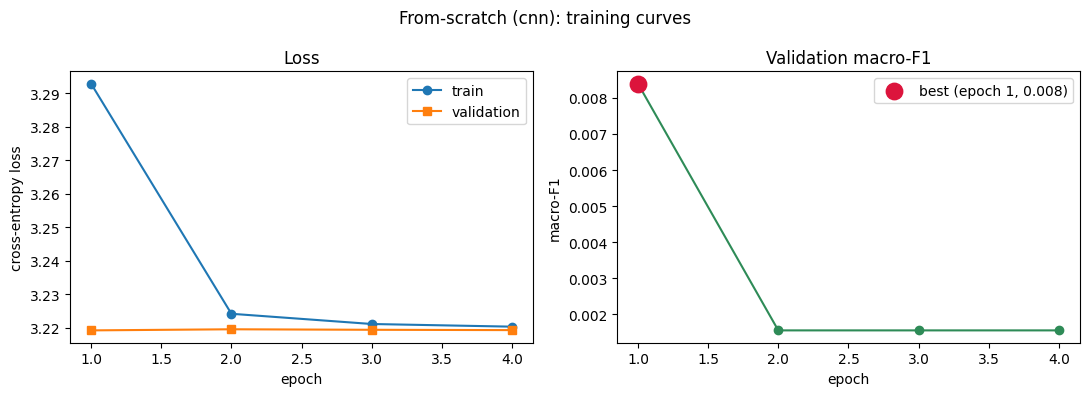

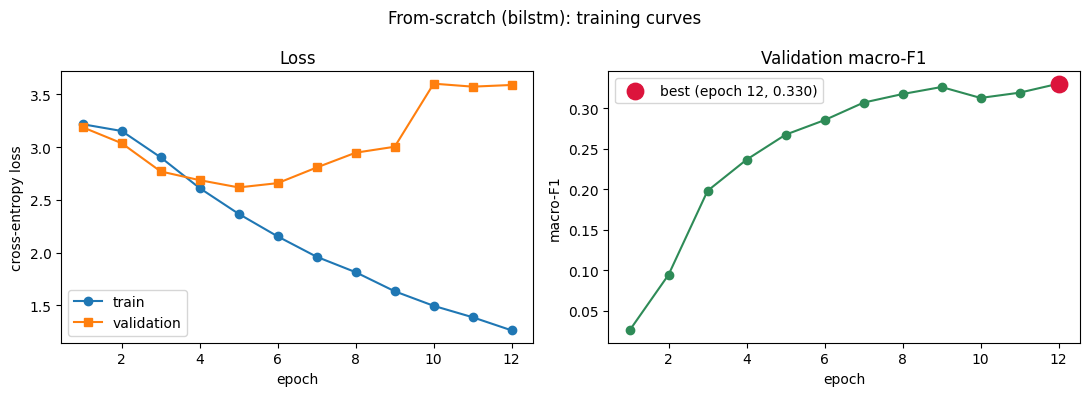

In [3]:
for arch in ("cnn", "bilstm"):
    plot_training_curves(
        runs[arch]["history"],
        f"From-scratch ({arch}): training curves",
        save_path=FIG_DIR / f"training_curves_scratch_{arch}.png",
    )

## Hyperparameter exploration

Vary embedding dimension and dropout on the better architecture. The
arch-comparison run (default kwargs) is the first candidate, and the grid adds
three more. The best candidate by validation macro-F1 is carried forward to the
test set, so the tuning selects the final model.

In [4]:
best_arch = max(runs, key=lambda a: runs[a]["best_val_f1"])
print(f"continuing with: {best_arch}")
# Three configurations, each distinct from the arch-comparison default
# (embed_dim=200, dropout=0.5), so the grid evaluates four unique settings.
grid = [
    {"embed_dim": 128, "dropout": 0.5},
    {"embed_dim": 128, "dropout": 0.3},
    {"embed_dim": 200, "dropout": 0.3},
]
candidates = [{"kwargs": {}, "model": runs[best_arch]["model"],
               "tok": runs[best_arch]["tok"], "history": runs[best_arch]["history"],
               "best_val_f1": runs[best_arch]["best_val_f1"]}]
for kw in grid:
    model, tok, hist = train_scratch_model(*tr_args, arch=best_arch, epochs=12,
                                           batch_size=64, model_kwargs=kw, verbose=False)
    val_f1 = max(h["val_macro_f1"] for h in hist)
    candidates.append({"kwargs": kw, "model": model, "tok": tok,
                       "history": hist, "best_val_f1": val_f1})
    print(f"{kw}  ->  val macro-F1 = {val_f1:.4f}")

best = max(candidates, key=lambda c: c["best_val_f1"])
print(f"\nselected: arch={best_arch}, kwargs={best['kwargs'] or 'defaults'}  "
      f"(val macro-F1 = {best['best_val_f1']:.4f})")

continuing with: bilstm


{'embed_dim': 128, 'dropout': 0.5}  ->  val macro-F1 = 0.3422


{'embed_dim': 128, 'dropout': 0.3}  ->  val macro-F1 = 0.3348


{'embed_dim': 200, 'dropout': 0.3}  ->  val macro-F1 = 0.3258

selected: arch=bilstm, kwargs={'embed_dim': 128, 'dropout': 0.5}  (val macro-F1 = 0.3422)


## Test-set evaluation of the best from-scratch model

In [5]:
test_loader = DataLoader(
    ScratchTextDataset(test["content"].tolist(), test["label"].tolist(), best["tok"], 400),
    batch_size=64, collate_fn=scratch_collate,
)
yt, yp, _ = _evaluate_scratch(best["model"], test_loader, get_device(), nn.CrossEntropyLoss())
test_metrics = compute_metrics(yt, yp, label_names)
print_report(test_metrics, f"From-scratch ({best_arch}): TEST")

(RESULTS_DIR / "scratch.json").write_text(json.dumps(
    {"model": f"scratch_{best_arch}", "kwargs": best["kwargs"],
     "test_macro_f1": test_metrics["macro_f1"],
     "test_accuracy": test_metrics["accuracy"],
     "history": best["history"]}, indent=2))


=== From-scratch (bilstm): TEST ===
  accuracy    : 0.3644
  macro-F1    : 0.3190
  weighted-F1 : 0.3735
  class                           P       R      F1      n
  Adult                       0.000   0.000   0.000     20
  News_and_Media              0.111   0.016   0.028     63
  Home_and_Garden             0.027   0.200   0.047     15
  Career_and_Education        0.077   0.065   0.071     46
  Business_and_Industry       0.222   0.049   0.080     82
  Arts_and_Entertainment      0.147   0.125   0.135     40
  Recreation_and_Hobbies      0.217   0.132   0.164     38
  Internet_and_Telecom        0.163   0.179   0.171     78
  Pets_and_Animals            0.150   0.522   0.233     23
  People_and_Society          0.250   0.260   0.255    100
  Shopping                    0.254   0.288   0.270     52
  Science                     0.219   0.493   0.303     67
  Computer_and_Electronics    0.236   0.507   0.322     67
  Travel                      0.308   0.400   0.348     40
  Autos_a

2492

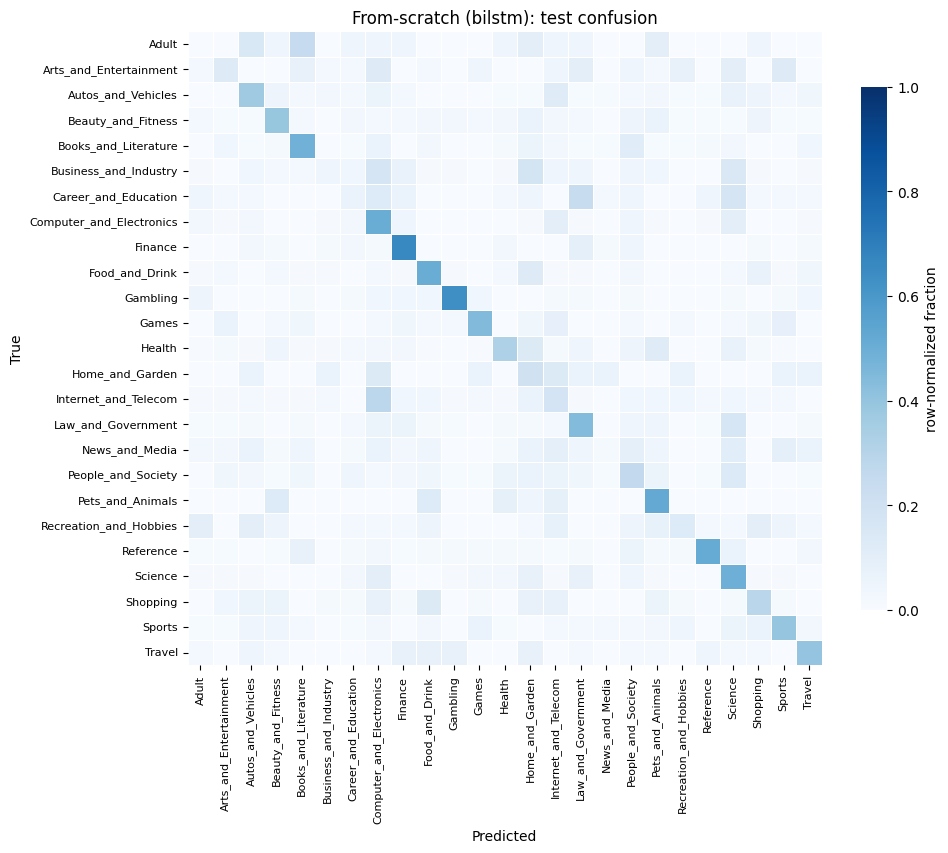

In [6]:
cm = confusion(yt, yp, len(label_names))
ax = plot_confusion_matrix(cm, label_names, f"From-scratch ({best_arch}): test confusion")
ax.figure.tight_layout()
ax.figure.savefig(FIG_DIR / "confusion_scratch.png", dpi=150)

## Takeaway

On this corpus a from-scratch CNN/BiLSTM learns a usable signal but may not beat
the TF-IDF baseline, because limited data bounds a randomly-initialized
embedding. The gain from large-scale pre-training is what notebook 04 tests.